The following notebook contains a brief tutorial on data importation and preprocessing in python. In this tutorial we will use a publicly available Automatic Identification system (AIS) dataset from a danish strait. AIS is a standardized protocol that allows ships to broadcast their position and other information relevant to maritime safety and international regulations. Any AIS receiver in range can read these messages. In this first tutorial we will show how we can import the data stored in a csv file into a useable form in python. Next we will discuss strategies for handling incomplete or missing data, preparing data for machine learning techniques. Finally, we will also show how one can quickly visualize data using matplotlib.

In [28]:
import pandas as pd

What is pandas? Pandas is a python library that is used primarily for data analysis. It has many useful function including ones that allow for simple imports into python from common data formats such as json or csv. The heart of pandas is the pandas dataframe. Dataframes provide many capabilities to modify and extract information from the stored data.  

In [ ]:
Complete_dataset=pd.read_csv('ais_data.csv')
print(Complete_dataset)

In [ ]:
In this tabular dataset we have many data fields (i.e features). Some data fields are not always filled or have a placeholder value such as "unknown". The data fields are as follows:

mmsi:This is an id for a specific vessel 

navigational status: Vessels provide what maratime activities they are conducting, especially if they limit their maneuvrability (fishing)

sog:speed over ground in (knots)

cog:course over ground (degrees), where the boat is going

heading: Direction the ship is pointing

shiptype:Type of ship that is transmitting

width: Width of the ship (how wide it is)

length: Length of the ship

draught: How deep in the water the ship extends (important for navigation)

It goes without saying that the key to making good decisions regarding preprocessing is to understand the data you are trying to analyze thoroughly. This sometimes requires some investigation to determine exactly how to structure the data properly (is the data time-series, are certain features relevant? etc.). 



        Unnamed: 0       mmsi      navigationalstatus   sog    cog  heading  \
0                0  219019621           Unknown value   0.0   86.0     86.0   
1                1  265628170           Unknown value   0.0  334.5      NaN   
2                2  219005719           Unknown value   0.0  208.7      NaN   
3                3  219028066           Unknown value   0.0    NaN      NaN   
4                4  212584000                  Moored   0.0  153.0    106.0   
...            ...        ...                     ...   ...    ...      ...   
358346      387577  236125000  Under way using engine  11.0  171.9    169.0   
358347      387578  209717000  Under way using engine  16.6  341.6    343.0   
358348      387579  257182000  Under way using engine  20.6  340.7    341.0   
358349      387580  219007697           Unknown value  34.9   96.2      NaN   
358350      387581  261054050  Under way using engine  11.5  315.0    310.0   

           shiptype  width  length  draught  
0    

Missing data and incomplete data:

When we are creating our training dataset in a supervised learning context we frequently need to clean our dataset for missing and incomplete data. The action we take in this case is dependent on several factors. The first is how much data we have, how comfortable are we with the features we have (sometimes features can be very abstract and difficult to interpret) and do we expect our classifier when trained to have to handle data with incomplete data. 

Option 1:

The first safest option is to not use any data that has incomplete features in the training set, this can be a good option especially if the features are challenging to interpret so we can't easily determine a reasonable value to replace our missing feature.


Option 2:

The second option is to replace data with a standard value such as the mean value, the previous value or use a regression model to calculate the value. Option 2 requires careful 


First we will determine how many of our samples have missing data.

In [ ]:
#Here calculate the number NaNs or incomplete values for each feature
rows_with_NaNs=Complete_dataset[
    Complete_dataset.isna().any(axis=1) |
    (Complete_dataset == "unknown value").any(axis=1)
]#isna() function determines if there are any NaN values in each row and we also check for unknown values as well

print(rows_with_NaNs)
Fraction_of_rows_with_NaN=len(rows_with_NaNs)/len(Complete_dataset)
print(Fraction_of_rows_with_NaN)

        Unnamed: 0       mmsi  navigationalstatus   sog    cog  heading  \
0                0  219019621       Unknown value   0.0   86.0     86.0   
1                1  265628170       Unknown value   0.0  334.5      NaN   
2                2  219005719       Unknown value   0.0  208.7      NaN   
3                3  219028066       Unknown value   0.0    NaN      NaN   
6                6  219006116       Unknown value   0.0    0.0      NaN   
...            ...        ...                 ...   ...    ...      ...   
358325      387556  219012671  Engaged in fishing   7.7  323.8    326.0   
358327      387558  219007697       Unknown value  44.7   96.4      NaN   
358332      387563  219007697       Unknown value  42.5   96.5      NaN   
358343      387574  219007697       Unknown value  37.4   96.1      NaN   
358349      387580  219007697       Unknown value  34.9   96.2      NaN   

           shiptype  width  length  draught  
0           Fishing    4.0     9.0      NaN  
1      

Next, using our knowledge of AIS we will try to replace a portion of the missing values. Firstly, as course over ground and heading are very similar (but technically distinct values) if either one of these values is valid and the other is missing we will replace for a given sample. Secondly, for the same mmsi number (the same ship) we will assume that ships maintain the same course and speed as previous values if they are missing. For static values such as length,width and draught any missing values will be replaced if any of the samples for the same mmsi number are present. In terms of missing navigational status information, we will simply treat this as a separate class in our categorical classification problem. Finally, we must handle the cases where a feature has invalid data for all samples of a given mmsi number (ship). A tempting option would be to use a mean value for a given class of ship to replace the missing value, however if our objective is to classify ships based upon their other features, then this could add bias to our experiment (our classifier could learn the significance of a certain inputted value rather than make classifications based upon the true available information. Hence, we will show we can replace these values with zeros to still allow us to use the data.

In [40]:
#First we will see if we can recover any static data using the mmsi number
#This takes a while given the large amount of data (1 hour+)
for _, current_row in Complete_dataset.iterrows():
    current_mmsi = current_row['mmsi']
    interim_dataframe = Complete_dataset.loc[
    Complete_dataset['mmsi'] == current_mmsi
].copy()

    #Next we conduct the following operations
    #Taking the interim dataframe, any cog, sog or heading info
    mask = interim_dataframe['cog'].isna() & interim_dataframe['heading'].notna()
    interim_dataframe.loc[mask, 'cog'] = interim_dataframe.loc[mask, 'heading']
    interim_dataframe['cog'] = interim_dataframe['cog'].ffill()
    #We assume if cog or heading information is missing we will assume they are the same
    interim_dataframe['sog'] = interim_dataframe['sog'].ffill()
    #sog information we will assume that it is the same as the last instance for the same mmsi
    mask = interim_dataframe['heading'].isna() & interim_dataframe['cog'].notna()
    interim_dataframe.loc[mask, 'heading'] = interim_dataframe.loc[mask, 'cog']
    interim_dataframe['heading'] = interim_dataframe['heading'].ffill()
    #Match with cog if possible
    interim_dataframe['width'] = interim_dataframe['width'].ffill()
    #Match with any previous value of the same mmsi
    interim_dataframe['length'] = interim_dataframe['length'].ffill()
    #match with any previous value of the same mmsi
    interim_dataframe['draught'] = interim_dataframe['draught'].ffill()
    #Next given all these changes we need to 
    Complete_dataset[
    Complete_dataset['mmsi'] == current_mmsi
]=interim_dataframe

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

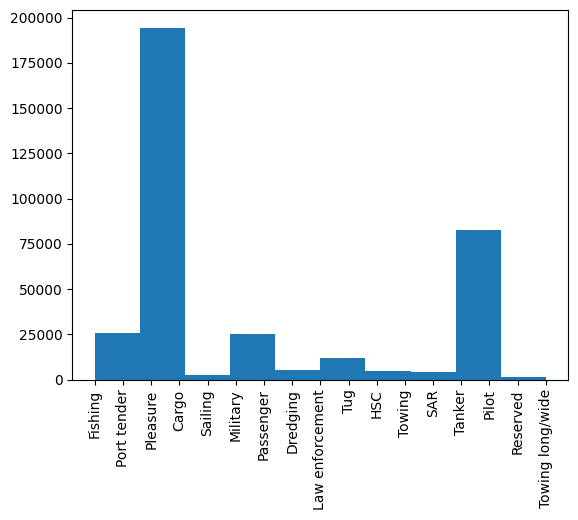

In [41]:
#Graphs
import matplotlib.pyplot as plt
shiptype=Complete_dataset['shiptype']
plt.hist(shiptype)
plt.title("Shiptype")
plt.xticks(rotation='vertical')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

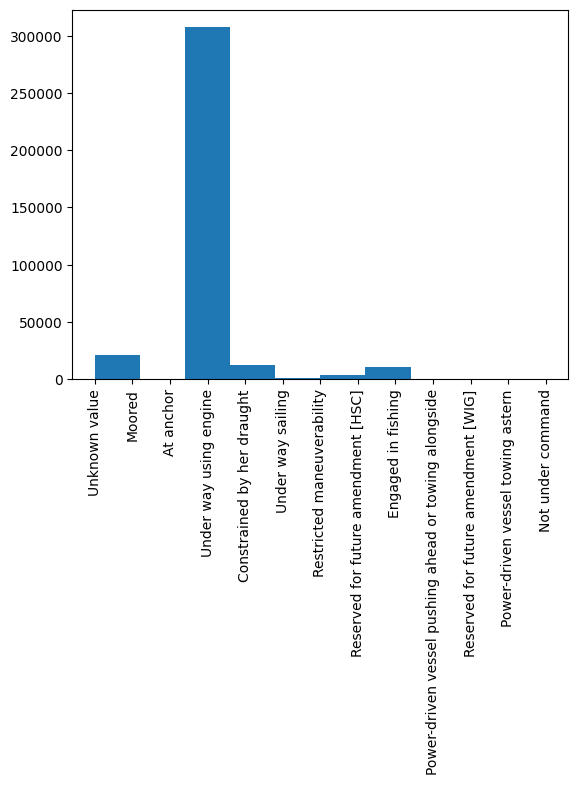

In [42]:
navstat=Complete_dataset['navigationalstatus']
plt.hist(navstat)
plt.title("Navigational Status")
plt.xticks(rotation='vertical')

(array([4.40610e+04, 1.31281e+05, 6.41310e+04, 5.40600e+04, 4.13710e+04,
        1.64550e+04, 1.58300e+03, 2.32700e+03, 0.00000e+00, 9.00000e+00]),
 array([ 1. ,  8.7, 16.4, 24.1, 31.8, 39.5, 47.2, 54.9, 62.6, 70.3, 78. ]),
 <BarContainer object of 10 artists>)

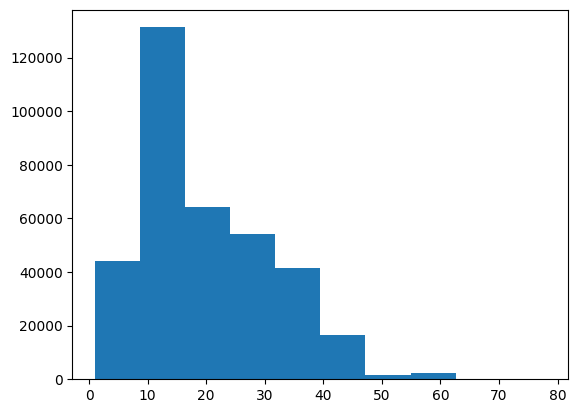

In [43]:
#width
width=Complete_dataset['width']
plt.hist(width)
plt.title("Ship Width")

(array([6.89920e+04, 1.44077e+05, 1.01178e+05, 3.68290e+04, 1.75000e+03,
        2.35800e+03, 0.00000e+00, 0.00000e+00, 4.60000e+01, 1.00000e+00]),
 array([  2. ,  70.8, 139.6, 208.4, 277.2, 346. , 414.8, 483.6, 552.4,
        621.2, 690. ]),
 <BarContainer object of 10 artists>)

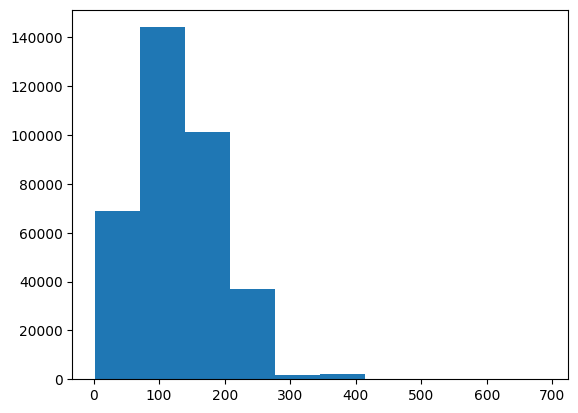

In [44]:
#length
length=Complete_dataset['length']
plt.hist(length)
plt.title("Ship Length")

(array([2.14570e+04, 1.02645e+05, 1.27099e+05, 4.51500e+04, 2.22790e+04,
        1.35420e+04, 1.10000e+01, 1.39000e+02, 3.00000e+00, 5.67000e+02]),
 array([ 0.4 ,  2.91,  5.42,  7.93, 10.44, 12.95, 15.46, 17.97, 20.48,
        22.99, 25.5 ]),
 <BarContainer object of 10 artists>)

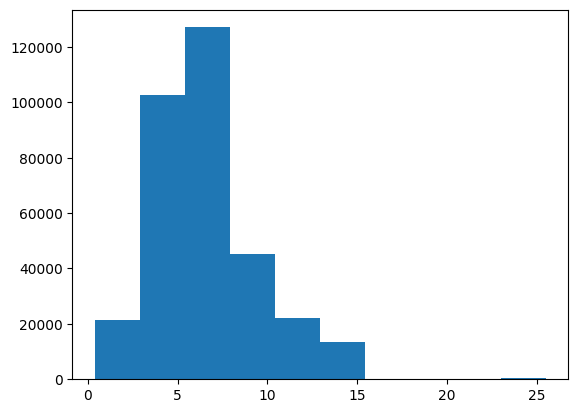

In [45]:
#draft
draft=Complete_dataset['draught']
plt.hist(draft)
plt.title("Ship Draught")

Next we will check how many NaNs are left after our changes

In [ ]:
rows_with_NaNs=Complete_dataset[
    Complete_dataset.isna().any(axis=1) |
    (Complete_dataset == "unknown value").any(axis=1)
]

print(rows_with_NaNs)
Fraction_of_rows_with_NaN=len(rows_with_NaNs)/len(Complete_dataset)
print(Fraction_of_rows_with_NaN)

        Unnamed: 0       mmsi  navigationalstatus   sog    cog  heading  \
0                0  219019621       Unknown value   0.0   86.0     86.0   
1                1  265628170       Unknown value   0.0  334.5    334.5   
2                2  219005719       Unknown value   0.0  208.7    208.7   
3                3  219028066       Unknown value   0.0    NaN      NaN   
6                6  219006116       Unknown value   0.0    0.0      0.0   
...            ...        ...                 ...   ...    ...      ...   
358325      387556  219012671  Engaged in fishing   7.7  323.8    326.0   
358327      387558  219007697       Unknown value  44.7   96.4     96.4   
358332      387563  219007697       Unknown value  42.5   96.5     96.5   
358343      387574  219007697       Unknown value  37.4   96.1     96.1   
358349      387580  219007697       Unknown value  34.9   96.2     96.2   

           shiptype  width  length  draught  
0           Fishing    4.0     9.0      NaN  
1      

In [ ]:
#Given that neural networks and other classifiers cannot handle NaN values we will replace the remaining NaN values with 0 to indicate to the classifier that the value is missing
#But still allow inference
#This is fairly simple in pandas
Complete_dataset = Complete_dataset.fillna(0)

In [ ]:
#Add graphs after NaN removal

shiptype=Complete_dataset['shiptype']
plt.hist(shiptype)
plt.title("Shiptype")
plt.xticks(rotation='vertical')

In [ ]:
navstat=Complete_dataset['navigationalstatus']
plt.hist(navstat)
plt.title("Navigational Status")
plt.xticks(rotation='vertical')

In [ ]:
#width
width=Complete_dataset['width']
plt.hist(width)
plt.title("Ship Width")

In [ ]:
length=Complete_dataset['length']
plt.hist(length)
plt.title("Ship Length")

In [ ]:
draft=Complete_dataset['draught']
plt.hist(draft)
plt.title("Ship Draught")

In the next seminar we will convert the data above into a format that can be fed into a neural network architecture. To accomplish this, encoding and normalization need to be conducted.


